In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#LOAD THE .CSV FILE

df = pd.read_csv("delaney-processed.csv")

In [4]:
df.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape: (1128, 10)

Columns:
Index(['Compound ID', 'ESOL predicted log solubility in mols per litre',
       'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
       'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre', 'smiles'],
      dtype='str')

Data types:
Compound ID                                            str
ESOL predicted log solubility in mols per litre    float64
Minimum Degree                                       int64
Molecular Weight                                   float64
Number of H-Bond Donors                              int64
Number of Rings                                      int64
Number of Rotatable Bonds                            int64
Polar Surface Area                                 float64
measured log solubility in mols per litre          float64
smiles                                                 str
dtype: object


In [6]:
df.describe()

,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
count,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000
mean,-2.988192,1.058511,203.937074,0.701241,1.390957,2.177305,34.872881,-3.050102
std,1.683220,0.238560,102.738077,1.089727,1.318286,2.640974,35.383593,2.096441
min,-9.702000,0.000000,16.043000,0.000000,0.000000,0.000000,0.000000,-11.600000
25%,-3.948250,1.000000,121.183000,0.000000,0.000000,0.000000,0.000000,-4.317500
50%,-2.870000,1.000000,182.179000,0.000000,1.000000,1.000000,26.300000,-2.860000
75%,-1.843750,1.000000,270.372000,1.000000,2.000000,3.000000,55.440000,-1.600000
max,1.091000,2.000000,780.949000,11.000000,8.000000,23.000000,268.680000,1.580000


In [29]:
#CHECK FOR MISSING VALUES

df.isnull().sum()

Compound ID                                        0
ESOL predicted log solubility in mols per litre    0
Minimum Degree                                     0
Molecular Weight                                   0
Number of H-Bond Donors                            0
Number of Rings                                    0
Number of Rotatable Bonds                          0
Polar Surface Area                                 0
measured log solubility in mols per litre          0
smiles                                             0
dtype: int64

In [8]:
df.duplicated().sum()    #NO DUPLICATED ROWS IF 0

np.int64(0)

In [13]:
#SET TARGET AND FEATURE VARIABLES

Target = 'measured log solubility in mols per litre'
features = [
    'Minimum Degree','Molecular Weight','Number of H-Bond Donors','Number of Rings','Number of Rotatable Bonds',
    'Polar Surface Area']

X = df[features]
y = df[Target]

In [14]:
print(X.shape)
print(y.shape)

(1128, 6)
(1128,)


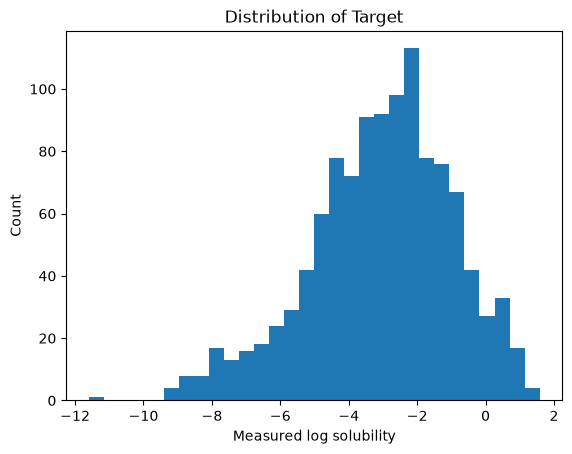

In [15]:
plt.hist(y, bins=30)
plt.xlabel('Measured log solubility')
plt.ylabel('Count')
plt.title('Distribution of Target')
plt.show()

In [28]:

# 3
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(df[(y < lower) | (y > upper)][                                  #POSSIBLE OUTLIERS
    ['Compound ID','Molecular Weight','Number of H-Bond Donors','Number of Rings',
     'Polar Surface Area','measured log solubility in mols per litre']
])
outlier = df[(y<lower) | (y>upper)]
print(f"Lower bound: {lower}")
print(f"Upper bound: {upper}")
print(f"Potential number of outliers:{len(outlier)}")

                       Compound ID  Molecular Weight  Number of H-Bond Donors  \
54               2,2',3,3',5,6-PCB           360.882                        0   
60         2,2',3,3',5,5',6,6'-PCB           429.772                        0   
181                     Etofenprox           376.496                        0   
220                       Perylene           252.316                        0   
272                   Deltamethrin           505.206                        0   
297        2,2',3,3',4,4',5,5'-PCB           429.772                        0   
497           Benzo(k)fluoranthene           252.316                        0   
603   2,2',3,3',4,4',5,5',6,6'-PCB           498.662                        0   
637                 Benzo(a)pyrene           252.316                        0   
676             Benzo[ghi]perylene           276.338                        0   
718                       Coronene           300.360                        0   
788                  1-Octad

In [25]:
outlier[['Molecular Weight','Number of Rings']].mean()

Molecular Weight    339.810000
Number of Rings       3.058824
dtype: float64

In [26]:
outlier.describe()       #CHARECTERISTICS OF OUTLIERS

,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
count,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000
mean,-7.001765,1.352941,339.810000,0.058824,3.058824,3.000000,6.308235,-8.909706
std,1.107205,0.492592,91.233663,0.242536,1.983387,4.974937,15.847626,0.750336
min,-9.589000,1.000000,226.448000,0.000000,0.000000,0.000000,0.000000,-11.600000
25%,-7.440000,1.000000,252.316000,0.000000,2.000000,0.000000,0.000000,-9.018000
50%,-6.896000,1.000000,360.882000,0.000000,2.000000,1.000000,0.000000,-8.699000
75%,-6.007000,2.000000,395.327000,0.000000,5.000000,1.000000,0.000000,-8.560000
max,-5.568000,2.000000,505.206000,1.000000,7.000000,16.000000,59.320000,-8.400000
